## Analysis of Socioeconomic Indicators

This notebook analyzes the cleaned datasets stored in MongoDB. The datasets include:

- birth rate by region and year
- gross regional product (GRP)
- GRP per capita
- employment rate
- housing price index (HPI)

The goal is to explore relationships between these indicators and identify patterns across regions and over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["mongo_db"]


def load_collection(name):
    df = pd.DataFrame(list(db[name].find()))
    if "_id" in df.columns:
        df = df.drop(columns="_id")
    return df

In [2]:
birthrate = load_collection("clean_birthrate")
grp = load_collection("clean_GRP")
grp_pc = load_collection("clean_GRP_per_capita")

print(birthrate.head())
print(grp.head())

  NUTS-Code  year  birth_rate
0     AT111  2002       7.260
1     AT111  2003       6.693
2     AT111  2004       7.744
3     AT111  2005       7.265
4     AT111  2006       6.942
  NUTS-Code            Region  year    GRP
0     AT111  Mittelburgenland  2000  572.0
1     AT111  Mittelburgenland  2001  611.0
2     AT111  Mittelburgenland  2002  599.0
3     AT111  Mittelburgenland  2003  636.0
4     AT111  Mittelburgenland  2004  645.0


## Merging Birth Rate and GRP Data

To analyze the relationship between economic output and birth rate, the two datasets are merged using:

- NUTS-Code (region)
- year (time)

This creates a combined dataset with both variables for each region-year observation.

In [8]:
merged = birthrate.merge(
    grp,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged.head())
print(merged.shape)

  NUTS-Code  year  birth_rate            Region    GRP
0     AT111  2002       7.260  Mittelburgenland  599.0
1     AT111  2003       6.693  Mittelburgenland  636.0
2     AT111  2004       7.744  Mittelburgenland  645.0
3     AT111  2005       7.265  Mittelburgenland  666.0
4     AT111  2006       6.942  Mittelburgenland  703.0
(770, 5)


In [9]:
correlation = merged["birth_rate"].corr(merged["GRP"])
print("Correlation between birth rate and GRP:", correlation)

Correlation between birth rate and GRP: 0.32538932592144815


## First Visualization: Birth Rate vs GRP

A scatter plot is used to visualize the relationship between gross regional product (GRP) and birth rate.

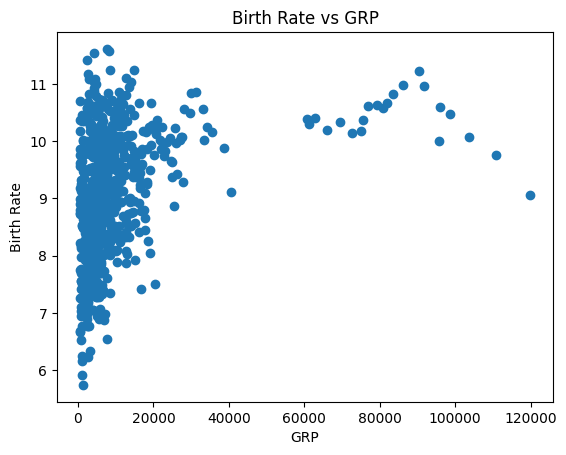

In [10]:
plt.figure()
plt.scatter(merged["GRP"], merged["birth_rate"])
plt.xlabel("GRP")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP")
plt.show()

## Observation

The scatter plot shows that the data points appear compressed along the horizontal axis. This is due to the large difference in scale between the variables:

- GRP values range from a few hundred to over 100,000
- Birth rates range only between approximately 5 and 12

This large variation in GRP is expected, as GRP represents the total economic output of a region. Larger regions with higher population and economic activity naturally have much higher GRP values than smaller regions.

However, this also highlights a conceptual issue: GRP is an absolute measure, while birth rate is a relative measure (per 1,000 people). As a result, comparing these two variables directly is not meaningful.

For a more appropriate analysis, GRP per capita will be used in the following step, as it provides a normalized measure of economic output that allows for better comparison across regions.

## Using GRP per Capita for Analysis

To obtain a more meaningful comparison, GRP per capita is used instead of total GRP. This normalizes economic output by population size and allows for better comparison between regions of different sizes.

In [12]:
merged_pc = birthrate.merge(
    grp_pc,
    on=["NUTS-Code", "year"],
    how="inner"
)

print(merged_pc.head())
print(merged_pc.shape)

  NUTS-Code  year  birth_rate            Region  GRP_per_capita
0     AT111  2002       7.260  Mittelburgenland         15900.0
1     AT111  2003       6.693  Mittelburgenland         16900.0
2     AT111  2004       7.744  Mittelburgenland         17200.0
3     AT111  2005       7.265  Mittelburgenland         17800.0
4     AT111  2006       6.942  Mittelburgenland         18800.0
(770, 5)


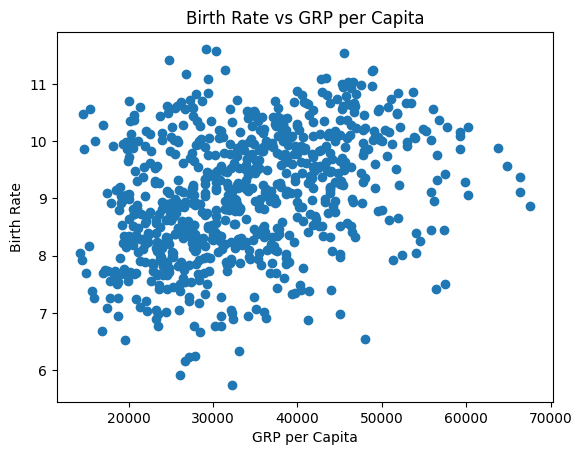

In [13]:
plt.figure()
plt.scatter(merged_pc["GRP_per_capita"], merged_pc["birth_rate"])
plt.xlabel("GRP per Capita")
plt.ylabel("Birth Rate")
plt.title("Birth Rate vs GRP per Capita")
plt.show()

In [14]:
correlation = merged_pc["birth_rate"].corr(merged_pc["GRP_per_capita"])
print("Correlation:", correlation)

Correlation: 0.3579988828395577


## Observation

The correlation between birth rate and GRP per capita is positive but moderate (approximately 0.36).

This suggests that regions with higher economic output per person tend to have slightly higher birth rates. However, the relationship is not strong, indicating that economic conditions alone do not fully explain differences in birth rates.

While there appears to be a tendency for more economically developed regions to have somewhat higher birth rates in this dataset, other factors—such as social structure, urbanization, or policy—are likely to play an important role.

Overall, GRP per capita shows some association with birth rate, but it is not a strong predictor on its own.